# 02 — Embeddings (ESM-2 Log-Ratio)

This notebook extracts **log-ratio scores** from ESM-2 model for all missense variants of the assessable dataset.

**Strategy:**

- Model: `esm2_t33_650M_UR50D` (650M parameters).
- Device: MPS (Apple Silicon).
- Truncation: 1024 residue window centered in the mutation position.
- Sequences containing the character 'X' (unknow aminoacid) are filtered before the inference.
- The inference operates by **unique proteins** (not by variant): the wild-type sequence is passed only once and the log-likelihood of all residues are extracted simultaneously.
- Output: `data/processed/variants_with_scores.parquet`.

In [1]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pandas import Series
from tqdm import tqdm
from transformers import EsmTokenizer, EsmForMaskedLM

from bio_var_pred.embeddings.log import get_log_probs_for_sequence, compute_log_ratio
from bio_var_pred.utils.paths import PROCESSED_DATA_DIR
from bio_var_pred.embeddings.assess import is_assessable, get_windowed_sequence


%load_ext dotenv
%dotenv

In [2]:
print(f"PyTorch version: {torch.__version__}")

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("MPS available")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("GPU available")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE.type}")

PyTorch version: 2.11.0
MPS available
Using device: mps


## 1. Load dataset and filter assessable data

In [3]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "variants.parquet")
print(f"Complete dataset: {df.shape}")
df.head()

Complete dataset: (76990, 16)


,id,chrom,pos_genomic,ref,alt,gene,transcript_id,pos_protein,aa_wt,aa_mut,label,protein_seq,af,ac,an,log_af
0,782833,1,966542,G,A,PLEKHN1,ENST00000379410,4,S,N,0,MGNSHCVPQAPRRLRASFSRKPSLKGNREDSARMSAGLPGPEAARS...,0.001402,2041.0,1455774.0,-2.853249
1,782834,1,966543,C,A,PLEKHN1,ENST00000379410,4,S,R,0,MGNSHCVPQAPRRLRASFSRKPSLKGNREDSARMSAGLPGPEAARS...,0.001402,2041.0,1455976.0,-2.853308
2,770481,1,972895,G,A,PLEKHN1,ENST00000379410,346,G,D,0,MGNSHCVPQAPRRLRASFSRKPSLKGNREDSARMSAGLPGPEAARS...,0.002800,3938.0,1406536.0,-2.552873
3,791106,1,973842,G,A,PLEKHN1,ENST00000379410,482,A,T,0,MGNSHCVPQAPRRLRASFSRKPSLKGNREDSARMSAGLPGPEAARS...,0.002036,2967.0,1457498.0,-2.691288
4,1320032,1,976215,A,G,PERM1,ENST00000341290,663,V,A,0,MEPRGGGSSQFSSCPGPASSGDQMQRLLQGPAPRPPGEPPGSPKSP...,0.791982,1097406.0,1385646.0,-0.101285


In [4]:
assessable_df = df.groupby("gene").filter(is_assessable).reset_index(drop=True)

print(f"Assessable variants: {len(assessable_df)}")
print(f"Assessable genes: {assessable_df['gene'].nunique()}")
print(f"Unique proteins (transcript_id): {assessable_df['transcript_id'].nunique()}")

Assessable variants: 54848
Assessable genes: 2253
Unique proteins (transcript_id): 3130


## 2. Filter sequences with character 'X'

The character 'X' represents an unknow aminoacid, and it's not part of the default ESM-2 vocabulary. These sequences would produce `[UNK]` tokens, silently corrupting the score.

In [5]:
has_x = assessable_df["protein_seq"].str.contains("X", regex=False)
print(f"Variants with character 'X' in the sequence: {has_x.sum()} ({100 * has_x.sum() / len(assessable_df):.2f}%)")
print(f"Affected genes: {assessable_df.loc[has_x, 'gene'].nunique()}")

Variants with character 'X' in the sequence: 23 (0.04%)
Affected genes: 19


In [6]:
assessable_df = assessable_df[~has_x].reset_index(drop=True)

print(f"Assessable variants (after X-filter): {len(assessable_df)}")
print(f"Assessable genes (after X-filter): {assessable_df['gene'].nunique()}")

Assessable variants (after X-filter): 54825
Assessable genes (after X-filter): 2253


### 2.1 Sanity check

In [7]:
test_seq = "A" * 2000
test_seq = test_seq[:500] + "M" + test_seq[501:]
windowed_seq, new_pos_protein = get_windowed_sequence(test_seq, pos_protein=501, window_size=1024)

assert windowed_seq[new_pos_protein - 1] == "M", "Incorrect mutation position after windowing"
assert len(windowed_seq) == 1024
print(f"Sanity check OK - new protein position: {new_pos_protein}, residue: {windowed_seq[new_pos_protein - 1]}")

Sanity check OK - new protein position: 501, residue: M


## 3. Load ESM-2 model

In [8]:
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
HF_TOKEN = os.environ.get("HF_TOKEN")

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)

print(f"Loading model: {MODEL_NAME}")
model = EsmForMaskedLM.from_pretrained(MODEL_NAME, token=HF_TOKEN)
model = model.to(DEVICE)
model.eval()

print(f"Model loaded and in evaluation mode")

Loading tokenizer: facebook/esm2_t33_650M_UR50D
Loading model: facebook/esm2_t33_650M_UR50D


Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

Model loaded and in evaluation mode


## 3.1 Log-likelihood and log-ratio extraction

ESM-2 is a Masked Language Model (MLM). In order to extract the probability distribution on all aminoacids in a given position, we pass the raw sequence, **without masking**, and use output logits directly - similar approach of the pseudo-log-likelihood by position, as mentioned by Meier et al. (2021) and Brandes et al. (2023).

In [9]:
WINDOW_SIZE = 1024
CHECKPOINT_EVERY = 500
CHECKPOINT_PATH = PROCESSED_DATA_DIR / "checkpoint_esm2_scores.parquet"

# Resume if checkpoint exists
if CHECKPOINT_PATH.exists():
    checkpoint_df = pd.read_parquet(CHECKPOINT_PATH)
    processed_ids = set(checkpoint_df["id"].tolist())
    print(f"Found checkpoint: {len(processed_ids)} variants already processed")
else:
    checkpoint_df = pd.DataFrame()
    processed_ids = set()
    print(f"No checkpoint found. Initializing from scratch")

# Not yet processed subset
remaining_df = assessable_df[~assessable_df["id"].isin(processed_ids)].reset_index(drop=True)
print(f"Remaining variants: {len(remaining_df)}")

Found checkpoint: 54825 variants already processed
Remaining variants: 0


In [10]:
batch_results = []

for i, (_, row) in enumerate(tqdm(remaining_df.iterrows(), total=len(remaining_df), desc="ESM-2 log-ratio")):
    seq = row["protein_seq"]
    pos = int(row["pos_protein"])
    aa_wt = row["aa_wt"]
    aa_mut = row["aa_mut"]

    windowed_seq, new_pos_protein = get_windowed_sequence(seq, pos_protein=pos, window_size=WINDOW_SIZE)

    try:
        log_probs = get_log_probs_for_sequence(windowed_seq, model, tokenizer, DEVICE)
        score = compute_log_ratio(log_probs, new_pos_protein, aa_wt, aa_mut, tokenizer)
    except Exception as e:
        score = None

    batch_results.append({"id": row["id"], "esm2_log_ratio": score})

    # Periodic checkpoint
    if (i + 1) % CHECKPOINT_EVERY == 0:
        batch_df = pd.DataFrame(batch_results)
        checkpoint_df = pd.concat([checkpoint_df, batch_df], ignore_index=True)
        checkpoint_df.to_parquet(CHECKPOINT_PATH, index=False)
        batch_results = []
        print(f"\tSaved checkpoint: {len(checkpoint_df)} variants accumulated")

# Store remaining residue
if batch_results:
    batch_df = pd.DataFrame(batch_results)
    checkpoint_df = pd.concat([checkpoint_df, batch_df], ignore_index=True)
    checkpoint_df.to_parquet(CHECKPOINT_PATH, index=False)

print(f"\nInference concluded. Total processed: {len(checkpoint_df)} variants")

ESM-2 log-ratio: 0it [00:00, ?it/s]


Inference concluded. Total processed: 54825 variants


## 4. Merge scores with assessable dataset

In [11]:
scores_df = pd.read_parquet(CHECKPOINT_PATH)

assessable_df = assessable_df.merge(scores_df, on="id", how="left")

n_valid = assessable_df["esm2_log_ratio"].notna().sum()
n_total = len(assessable_df)
print(f"Valid scores: {n_valid}/{n_total} ({100 * n_valid / n_total:.2f}%)")

Valid scores: 54825/54825 (100.00%)


In [12]:
print(assessable_df.shape)
assessable_df.head(10)

(54825, 17)


,id,chrom,pos_genomic,ref,alt,gene,transcript_id,pos_protein,aa_wt,aa_mut,label,protein_seq,af,ac,an,log_af,esm2_log_ratio
0,387476,1,1020183,G,C,AGRN,ENST00000379370,4,R,P,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.000994,1176.0,1182524.0,-3.002398,-3.081203
1,263204,1,1041218,C,T,AGRN,ENST00000379370,258,T,I,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001124,1484.0,1319880.0,-2.949098,-6.396329
2,128291,1,1041583,A,G,AGRN,ENST00000379370,353,Q,R,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.001738,2529.0,1454750.0,-2.759838,-1.381803
3,263158,1,1041648,G,T,AGRN,ENST00000379370,375,A,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.006713,9794.0,1458968.0,-2.173085,-5.311023
4,263163,1,1043382,G,A,AGRN,ENST00000379370,510,G,S,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.010539,15353.0,1456748.0,-1.977192,-5.103392
5,263165,1,1043594,G,A,AGRN,ENST00000379370,554,V,M,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.005936,8623.0,1452696.0,-2.226516,-8.437843
6,210106,1,1044017,G,A,AGRN,ENST00000379370,665,E,K,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.002384,3473.0,1456916.0,-2.622728,-6.664642
7,128294,1,1044368,A,T,AGRN,ENST00000379370,728,E,V,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.038086,55625.0,1460502.0,-1.419232,-8.373755
8,263169,1,1045172,G,A,AGRN,ENST00000379370,756,A,T,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.000923,1348.0,1459992.0,-3.034656,-3.443408
9,263173,1,1045751,A,G,AGRN,ENST00000379370,852,Q,R,0,MAGRSHPGPLRPLLPLLVVAACVLPGAGGTCPERALERREEEANVV...,0.006093,8902.0,1461094.0,-2.215190,-3.286973


## 5. Scores inspection

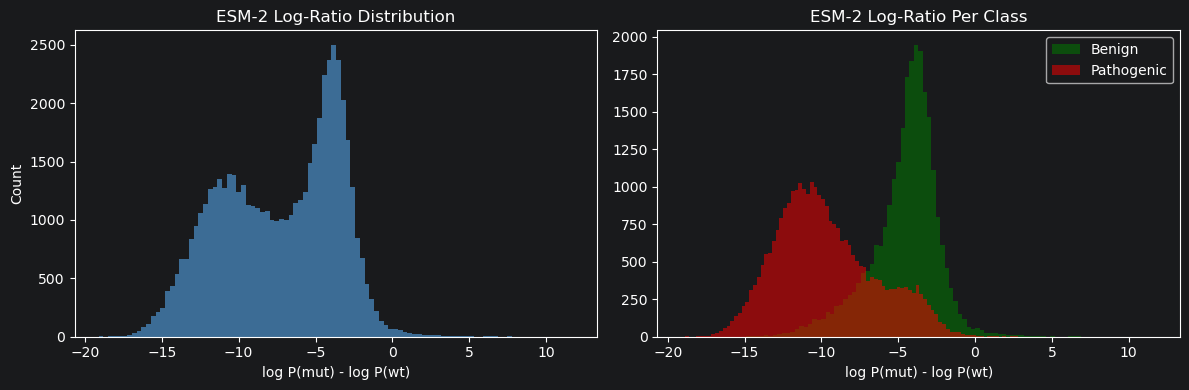

In [13]:
valid_scores = assessable_df.dropna(subset=["esm2_log_ratio"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(valid_scores["esm2_log_ratio"], bins=100, color="steelblue", alpha=0.8)
axes[0].set_title("ESM-2 Log-Ratio Distribution")
axes[0].set_xlabel("log P(mut) - log P(wt)")
axes[0].set_ylabel("Count")

for label, color, name in [(0, "green", "Benign"), (1, "red", "Pathogenic")]:
    subset = valid_scores[valid_scores["label"] == label]["esm2_log_ratio"]
    axes[1].hist(subset, bins=100, color=color, label=name, alpha=0.5)

axes[1].set_title("ESM-2 Log-Ratio Per Class")
axes[1].set_xlabel("log P(mut) - log P(wt)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
print(f"Statistics per class:")
valid_scores.groupby("label")["esm2_log_ratio"].describe()

Statistics per class:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,25199.0,-4.578001,2.216682,-16.898588,-5.596397,-4.207508,-3.237846,11.791468
1,29626.0,-9.700178,3.243699,-19.120049,-12.037565,-10.195054,-7.685156,5.470277


## 6. Verification of position consistency (sample)

In [15]:
def verify_position(row: Series):
    windowed_seq, new_pos_protein = get_windowed_sequence(
        row["protein_seq"],
        int(row["pos_protein"]),
        WINDOW_SIZE
    )

    return windowed_seq[new_pos_protein - 1] == row["aa_wt"]


sample = assessable_df.sample(1000, random_state=42)
consistency = sample.apply(verify_position, axis=1)
print(f"Position consistency (1000 sample): {consistency.mean():.2%}")

Position consistency (1000 sample): 100.00%


## 7. Save final output

In [16]:
output_path = PROCESSED_DATA_DIR / "variants_with_scores.parquet"
assessable_df.to_parquet(output_path, index=False)

print(f"Saved at: {output_path}")
print(f"Final shape: {assessable_df.shape}")
print(f"Columns: {list(assessable_df.columns)}")

Saved at: /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/variants_with_scores.parquet
Final shape: (54825, 17)
Columns: ['id', 'chrom', 'pos_genomic', 'ref', 'alt', 'gene', 'transcript_id', 'pos_protein', 'aa_wt', 'aa_mut', 'label', 'protein_seq', 'af', 'ac', 'an', 'log_af', 'esm2_log_ratio']
